**The iLQR on the cart and pole system**

Consider the cart-and-pole system here depicted:
<div>
<img src="https://drive.google.com/uc?export=view&id=1Yu5zZ57OEEYZ678yWLaU7h-Wq3M9vV9E" width="200">
</div>
whose dynamics follows the following equations:

\begin{align}
  \ddot{\theta}&=\frac{g \sin(\theta)\,+\,\cos(\theta) \left[ \frac{-F\,-\,m_p\,l\,\dot{\theta}^2 \sin \left(\theta\right)}{m_c\,+\,m_p}\right]-\frac{\mu_p\dot{\theta}}{m_p\,l}}{l\,\left[\frac{4}{3}-\frac{m_p\,cos^2\left(\theta\right)}{m_c\,+\,m_p}\right]}
\end{align}
>>>>>>>>>>>>>>>>>>>>>>>>$(*)$

\begin{align}
  \ddot{p}_c&=\frac{F\,+\,m_p\,l\,\left[\dot{\theta}^2\,\sin\left(\theta\right)\,-\,\ddot{\theta}\,\cos(\theta)\right]}{m_c\,+\,m_p}
\end{align}

where $g = 9.8\,\text{m/sec}$ is the gravitational acceleration, $m_c = 1\,\text{kg}$ is the cart mass, $m_p = 0.1\,\text{kg}$ is the pole mass, $l = 0.5\,\text{m}$ is the half-pole length, $\mu_p = 0.000002$ is the pole on cart friction coefficient.

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.io import loadmat
import jax.numpy as jnp
from jax import jacfwd
from jax import config
from numpy.linalg import matrix_power
from scipy.linalg import solve_discrete_are
from scipy.signal import cont2discrete
from IPython.display import HTML
import matplotlib.animation as animation
from matplotlib import rc
import matplotlib

matplotlib.rcParams['animation.embed_limit'] = 2**128
rc('animation', html='jshtml')
config.update("jax_enable_x64", True)

In [4]:
class InvertedPendulum:
  def __init__(self, m_c, m_p, g, l, u_p):
    self.m_c = m_c
    self.m_p = m_p
    self.g = g
    self.l = l
    self.u_p = u_p

  ############################################################################
  ## Computation of the non-linear system
  ############################################################################

  def compute(self, t, x: np.array, u: float) -> jnp.array:
    dx = [None for _ in range(4)]
    dx[0] = x[1]
    dx[1] = (self.g*jnp.sin(x[0]) + jnp.cos(x[0])*((-u -self.m_p*self.l*jnp.sin(x[0])*x[1]**2)/(self.m_c + self.m_p)) - (self.u_p*x[1])/(self.m_p*self.l))/(self.l*(4/3 - (self.m_p*jnp.cos(x[0])**2)/(self.m_c + self.m_p)))
    dx[2] = x[3]
    dx[3] = (u + self.m_p*self.l*(jnp.sin(x[0])*x[1]**2 - dx[1]*jnp.cos(x[0])))/(self.m_c + self.m_p)

    return jnp.asarray(dx)

  def linearize(self, x_eq: np.array, u_eq: float) -> tuple:
    A = jacfwd(lambda x: self.compute(0, x, u_eq))(x_eq)
    B = jacfwd(lambda u: self.compute(0, x_eq, u))(u_eq)

    B = B.reshape(B.shape[0], 1)

    return(A, B)

  def render_cart_pole(self, time: np.array, state_evolution: np.array, sample_time: float):
    fig, ax = plt.subplots()

    cart_position = state_evolution[2, :]
    pole_angle = state_evolution[0, :]

    cart_width = 0.3
    cart_height = 0.2

    cart = plt.Rectangle((cart_position[0] - cart_width/2, 0), cart_width, cart_height, color='blue')
    pole_length = self.l*2
    pole = plt.Line2D([cart_position[0], cart_position[0] + pole_length*np.sin(pole_angle[0])],
                     [cart_height, cart_height + pole_length*np.cos(pole_angle[0])], color='black', linewidth=2)
    ax.set(xlim=[-2, 2], ylim=[-2, 2], xlabel='Position X [m]', ylabel='Position Y [m]')

    ax.grid()

    ax.add_patch(cart)
    ax.add_line(pole)

    def update(frame):
      cart.set_x(cart_position[frame] - cart_width/2)
      pole.set_data([cart_position[frame], cart_position[frame] + pole_length*np.sin(pole_angle[frame])],
                     [cart_height, cart_height + pole_length*np.cos(pole_angle[frame])])
      return (cart, pole)


    ani = animation.FuncAnimation(fig=fig, func=update, frames=state_evolution.shape[1], interval=sample_time*1000)
    plt.close()

    return ani

In [5]:
def simulate(sys: InvertedPendulum, x_init: np.array, u_seq: np.array, sample_time: float) -> tuple:
  t_eval = np.linspace(0, sample_time*u_seq.shape[0], u_seq.shape[0] + 1)
  result = np.empty((x_init.shape[0], t_eval.shape[0]))
  result[:, 0] = x_init

  # simulation
  for i in range(0, t_eval.shape[0] - 1):
    tspan = [t_eval[i], t_eval[i + 1]]
    sol = solve_ivp(fun=lambda t, x: sys.compute(t, x, u_seq[i]), t_span=tspan, y0=x_init, t_eval=tspan, method='RK45', rtol=1e-3, atol=1e-6)
    x_init = sol.y[:, 1]
    result[:, i+1] = x_init
  return (t_eval, result)

In [6]:
def plot_solutions(t, solutions):
  # Create a figure with 2x2 subplots
  fig, axes = plt.subplots(1, 2, figsize=(10, 3))
  # Subplot 1 (left)
  axes[0].plot(t, solutions[0, :], label=r'theta')
  axes[0].set_title(r'$\theta(t)$')
  axes[0].legend()
  # Subplot 2 (right)
  axes[1].plot(t, solutions[0, :], label='theta')
  axes[1].plot(t, solutions[1, :], label='d(theta)')
  axes[1].plot(t, solutions[2, :], label='p')
  axes[1].plot(t, solutions[3, :], label='d(p)')
  axes[1].set_title(r'$\theta(t)$, $\dot{\theta}(t)$, $p(t)$, $\dot{p}(t)$')
  axes[1].legend()
  # Adjust layout
  plt.tight_layout()
  # Show the plot
  plt.show()

1. Simulate the non-linear cart and pole system applying the provided control input sequence $\bar{u}^{(k)}$ with a sample time of 0.005 sec. Record the resulting state trajectory $\bar{x}^{(k)}$ with an initial state of $\theta=180^°$, $\dot{\theta}=0$, $p_c=0$, $\dot{p_c}=0$. Plot the resulting trajectory.


*Provide the code*:









































In [7]:
inv_pend = InvertedPendulum(m_c=1, m_p=0.1, g=9.8, l=0.5, u_p=0.000002)

In [8]:
## Simulation with controlled input

sampling_time = 0.005

u_s1 = loadmat('ilqr_u.mat')['input_traj']
u_s1 = u_s1.flatten()
u_s1 = u_s1.astype('float64')

x_init = np.array([np.pi, 0, 0, 0])

t_s1, solution_s1 = simulate(sys=inv_pend, x_init=x_init, u_seq=u_s1, sample_time=sampling_time)

plot_solutions(t_s1, solution_s1)

FileNotFoundError: [Errno 2] No such file or directory: 'ilqr_u.mat'

2. Linearize the non-linear cart and pole system around the nominal state-input trajectories $\{\bar{x}^{(k)},\bar{u}^{(k)}\}$ previously obtained, and store the time-varying matrices of the linearized system $\{A(k),B(k)\}$




*Provide the code:*


In [ ]:
def linerized_around_trajectory(state_evolution: np.array, u: np.array, sampling_time: float) -> dict:
  time_variant_linarization = {}
  time_variant_linarization["A"] = np.empty((u.shape[0], state_evolution.shape[0], state_evolution.shape[0]))
  time_variant_linarization["B"] = np.empty((u.shape[0], state_evolution.shape[0], 1))

  for i in range(u.shape[0]):
    x0 = state_evolution[:, i]
    A, B = inv_pend.linearize(x_eq=x0, u_eq=u[i])

    time_variant_linarization["A"][i] = A.copy()
    time_variant_linarization["B"][i] = B.copy()

  return time_variant_linarization.copy()

In [ ]:
time_variant_linearization = linerized_around_trajectory(state_evolution=solution_s1, u=u_s1, sampling_time=sampling_time)

time_variant_linearization["A"].shape, time_variant_linearization["B"].shape

3. Compute the discrete-time homogeneous representation of the linear time-varying cart and pole system obtained at point 2. and store the matrices of the homogeneous representation



*Provide the code*:

In [ ]:
# Computing discrete time matrices
C, D = np.eye(4), np.zeros((4, 1))

for i in range(time_variant_linearization["A"].shape[0]):
  A = time_variant_linearization["A"][i]
  B = time_variant_linearization["B"][i]
  ssdt = cont2discrete((A, B, C, D), dt=sampling_time)
  time_variant_linearization["A"][i] = ssdt[0].copy()
  time_variant_linearization["B"][i] = ssdt[1].copy()

# computing homogeneous representation

def compute_homogeneous_representation(A: np.array, B: np.array) -> dict:
  time_variant_hom_linearization = {}
  time_variant_hom_linearization["A"] = np.empty((A.shape[0], A.shape[1] + 1, A.shape[2] + 1))
  time_variant_hom_linearization["B"] = np.empty((B.shape[0], B.shape[1] + 1, B.shape[2]))

  for i in range(A.shape[0]):
    identity = np.eye(5)
    b = np.zeros((5, 1))

    identity[:4, :4] = A[i]
    b[:4] = B[i]
    time_variant_hom_linearization["A"][i] = identity.copy()
    time_variant_hom_linearization["B"][i] = b.copy()

  return time_variant_hom_linearization.copy()

time_variant_hom_linearization = compute_homogeneous_representation(A=time_variant_linearization["A"], B=time_variant_linearization["B"])

time_variant_hom_linearization["A"].shape, time_variant_hom_linearization["B"].shape

4.    Assume $Q=I$ and $R=1$ , the cost matrices for a swing up cart and pole task, and compute $\hat{Q}(k)=\begin{bmatrix}
Q & -q^{{(k)}^\top}\\
-q^{(k)} & d^{(k)}\end{bmatrix}$ where $\bar{x}^{{(k)}^\top} Q \bar{x}^{(k)}=d^{(k)}$ and $2\bar{x}^{{(k)}^\top} Q=2 q^{{(k)}^\top}$ for the entire nominal state trajectory  and store them

*Provide the code*:

In [ ]:
def compute_time_variant_homogeneous_q_matrix(state_evolution: np.array, Q: np.array, R: float) -> np.array:
  q_hat = np.empty((state_evolution.shape[1] - 1, Q.shape[0] + 1, Q.shape[1] + 1))

  # state_evolution.shape[1] - 1 = u.shape[0] because we want to have as much q_hat values as control inputs

  for i in range(state_evolution.shape[1] - 1):
    x = state_evolution[:, i].reshape(4, 1)

    q_temp = np.empty((5, 5))
    q_temp[:4, :4] = Q
    q_temp[:4, -1] = (-Q.T@x).flatten()
    q_temp[-1, :4] = (Q.T@x).flatten()
    q_temp[-1, -1] = x.T@Q@x
    q_hat[i] = q_temp.copy()

  return q_hat.copy()

Q = np.eye(4)
R = 1
Qk_hat = compute_time_variant_homogeneous_q_matrix(state_evolution=solution_s1, Q=Q, R=R)

In [ ]:
print(f'Qk_hat.shape {Qk_hat.shape}')

5.   Solve the finite-horizon LQR problem on the linearized version of the system and store the control gain matrices $\{K(k)\}$. Assume that $P_H=\begin{bmatrix}
I &0\\0 &0\end{bmatrix}$.

*Provide the code*:

In [ ]:
# terminal cost to compute recursively K(k)

P_H = np.zeros((5, 5))
P_H[:4, :4] = np.eye(4)

In [ ]:
def recursive_riccati_gain(time_varing_A: np.array, time_varing_B: np.array, time_varing_Q: np.array, R: float, P_H: np.array) -> tuple:

  horizon = time_varing_A.shape[0]

  A = time_varing_A
  B = time_varing_B

  Q = time_varing_Q

  P = np.empty((horizon, P_H.shape[0], P_H.shape[1]))
  kk = np.empty((horizon, time_varing_B.shape[2], time_varing_B.shape[1])) # I have a kk vector of horizon X 1 X 5 so I dont' have to take the transpose

  P[horizon - 1] = P_H
  a = np.linalg.inv(R + B[horizon - 1].T@P[horizon - 1]@B[horizon - 1])@B[horizon - 1].T@P[horizon - 1]@A[horizon - 1]
  kk[horizon - 1] = np.linalg.inv(R + B[horizon - 1].T@P[horizon - 1]@B[horizon - 1])@B[horizon - 1].T@P[horizon - 1]@A[horizon - 1]

  for k in range(horizon - 2, -1, -1):
    P[k] = A[k].T@P[k+1]@A[k] + Q[k] - A[k].T@P[k+1]@B[k]@np.linalg.inv(R + B[k].T@P[k+1]@B[k])@B[k].T@P[k + 1]@A[k]
    a = np.linalg.inv(R + B[k].T@P[k]@B[k])@B[k].T@P[k]@A[k]
    kk[k] = np.linalg.inv(R + B[k].T@P[k]@B[k])@B[k].T@P[k]@A[k]

  return (P, kk)

In [ ]:
P, kk = recursive_riccati_gain(time_varing_A=time_variant_hom_linearization["A"], time_varing_B=time_variant_hom_linearization["B"], time_varing_Q=Qk_hat, R=R, P_H=P_H)

6. Simulate the non-linear cart and pole system applying the computed control gain matrices $\{K(k)\}$ with a sample time of 0.005 sec. Record the resulting state and control input trajectory with an initial state of $\theta=180^°$, $\dot{\theta}=0$, $p_c=0$, $\dot{p_c}=0$. Plot the resulting trajectories

*Provide the code*:

In [ ]:
def ilqr_simulate_one_round(sys: InvertedPendulum, x_init: np.array, kk: np.array, nominal_input: np.array, nomial_trajectory: np.array, sample_time: float) -> tuple:

  steps = kk.shape[0] + 1
  t_eval = np.linspace(0, kk.shape[0]*sample_time, steps)

  result = np.empty((x_init.shape[0], t_eval.shape[0]))
  result[:, 0] = x_init

  u_seq = np.empty(kk.shape[0])

  # simulation
  for i in range(0, t_eval.shape[0] - 1):
    tspan = [t_eval[i], t_eval[i + 1]]

    error_x = (x_init - nomial_trajectory[:, i]).reshape(4, 1) # calculate the error
    x_hom = np.vstack((error_x, 1))
    u = np.dot(-kk[i], x_hom) + nominal_input[i]

    u_seq[i] = u[0, 0]

    sol = solve_ivp(fun=lambda t, x: sys.compute(t, x, u_seq[i]), t_span=tspan, y0=x_init, t_eval=tspan, method='RK45', rtol=1e-3, atol=1e-6)
    x_init = sol.y[:, 1]
    result[:, i+1] = x_init

  return (t_eval, result, u_seq)

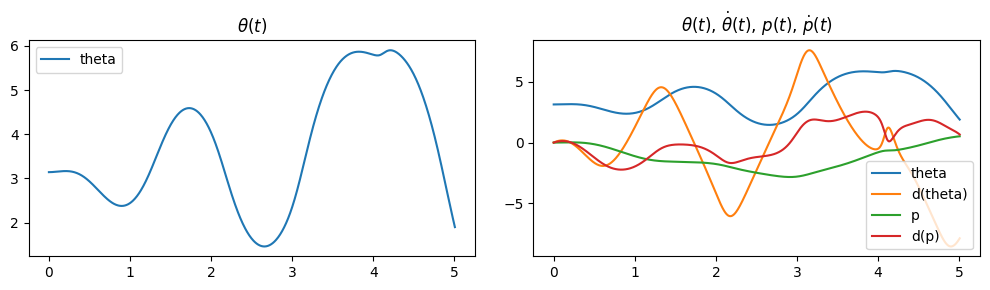

In [ ]:
t_eval, result_solution, u_seq = ilqr_simulate_one_round(sys=inv_pend, x_init=x_init, kk=kk, nominal_input=u_s1, nomial_trajectory=solution_s1, sample_time=sampling_time)

plot_solutions(t_eval, result_solution)

In [ ]:
ani = inv_pend.render_cart_pole(t_eval, result_solution, sample_time=sampling_time)

ani

Output hidden; open in https://colab.research.google.com to view.

This is the first iteration of the iLQR regulator. As we can see there is a little inprovement (change from 3-5 s) in the seconcond plot, but to have the desired behaviour we need more iteratons.